# Aufgabe 4

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.morphology import erosion

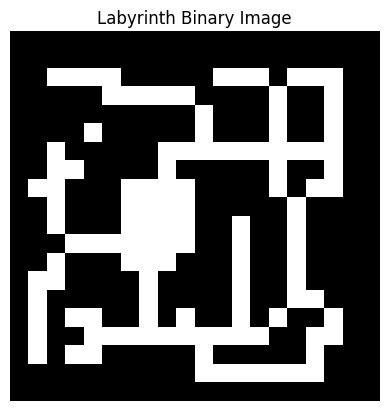

In [120]:
labyrinth_bin = imread("labyrinth_bin.png")

plt.imshow(labyrinth_bin, cmap='gray')
plt.title('Labyrinth Binary Image')
plt.axis('off')
plt.show()

## 4.1

Strukturelemente (1=Vordergrund, 0=Hintergrund, -1=egal):


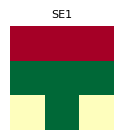

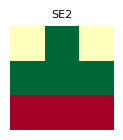

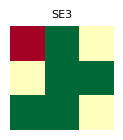

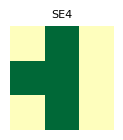

In [121]:
SE_1 = np.array([
    [-1,  -1, -1],
    [1,  1, 1],
    [0,  1, 0]], dtype=np.int8)

SE_2 = np.array([
    [0,  1, 0],
    [1,  1, 1],
    [-1, -1, -1]], dtype=np.int8)

SE_3 = np.array([
    [-1,  1, 0],
    [0,  1, 1],
    [1,  1, 0]], dtype=np.int8)

SE_4 = np.array([
    [0,  1, 0],
    [1,  1, 0],
    [0,  1, 0]], dtype=np.int8)

SEs = [SE_1, SE_2, SE_3, SE_4]

print("Strukturelemente (1=Vordergrund, 0=Hintergrund, -1=egal):")
for i, se in enumerate(SEs, 1):
    fig, ax = plt.subplots(figsize=(1.5, 1.5))
    ax.imshow(se, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_title(f'SE{i}', fontsize=8)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


## 4.2

In [122]:
def hmt(img, se):
    fg = (se == 1)
    bg = (se == 0)
    return erosion(img.astype(bool), fg) & erosion(~img.astype(bool), bg)

In [123]:
def hit_or_miss(img, se):
    h, w = img.shape
    out = np.zeros_like(img, dtype=bool)

    for y in range(1, h-1):
        for x in range(1, w-1):

            ok = True

            for dy in range(-1, 2):
                for dx in range(-1, 2):

                    val = se[dy+1, dx+1]

                    if val == -1:
                        continue

                    if img[y+dy, x+dx] != val:
                        ok = False
                        break

                if not ok:
                    break

            out[y, x] = ok

    return out

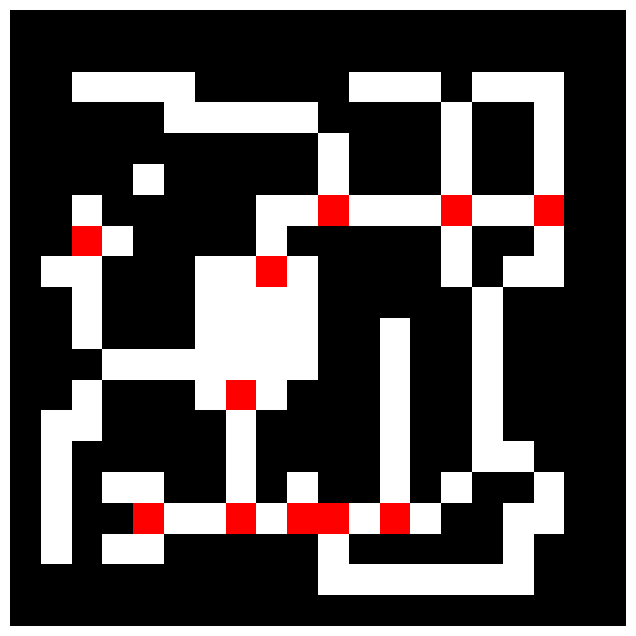

In [124]:
junctions = np.zeros_like(labyrinth_bin, dtype=bool)

for se in SEs:
    junctions |= hmt(labyrinth_bin.astype(int), se)

rgb = np.dstack([labyrinth_bin, labyrinth_bin, labyrinth_bin]).astype(float)

rgb[junctions] = [1,0,0]

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.axis("off")
plt.show()